In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [30]:
df = pd.read_csv(r'C:\Users\jenar\!clases\TC2004B-Jenaro\data\auto-mpg.csv')
df.head(4)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst


In [31]:
df.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model year', 'origin', 'car name'],
      dtype='object')

In [32]:
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [34]:
non_numeric_hp = df[~df['horsepower'].str.replace('.','',1).str.isnumeric()]['horsepower'].unique()
print('None-numeric horespower values', non_numeric_hp)

None-numeric horespower values ['?']


In [35]:
df['horsepower'].replace('?', np.nan, inplace=True)

df['horsepower'] = pd.to_numeric(df['horsepower'])

df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

In [36]:
mean_hp = df['horsepower'].mean()
df['horsepower'].fillna(mean_hp, inplace=True)
df.isnull().sum()

C:\Users\jenar\AppData\Local\Temp\ipykernel_20784\1696666304.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['horsepower'].fillna(mean_hp, inplace=True)


mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(4), int64(4), object(1)
memory usage: 28.1+ KB


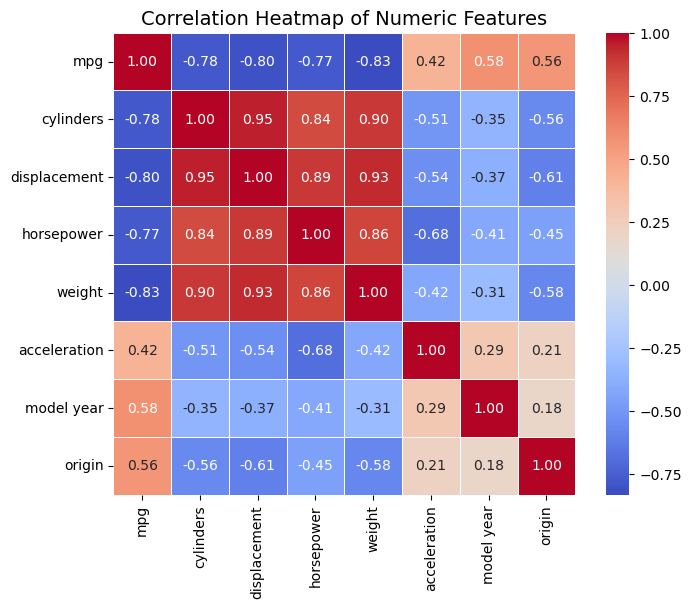

In [38]:
corr = df.select_dtypes(include=['float64', 'int64']).corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True, linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features", fontsize = 14)
plt.show()

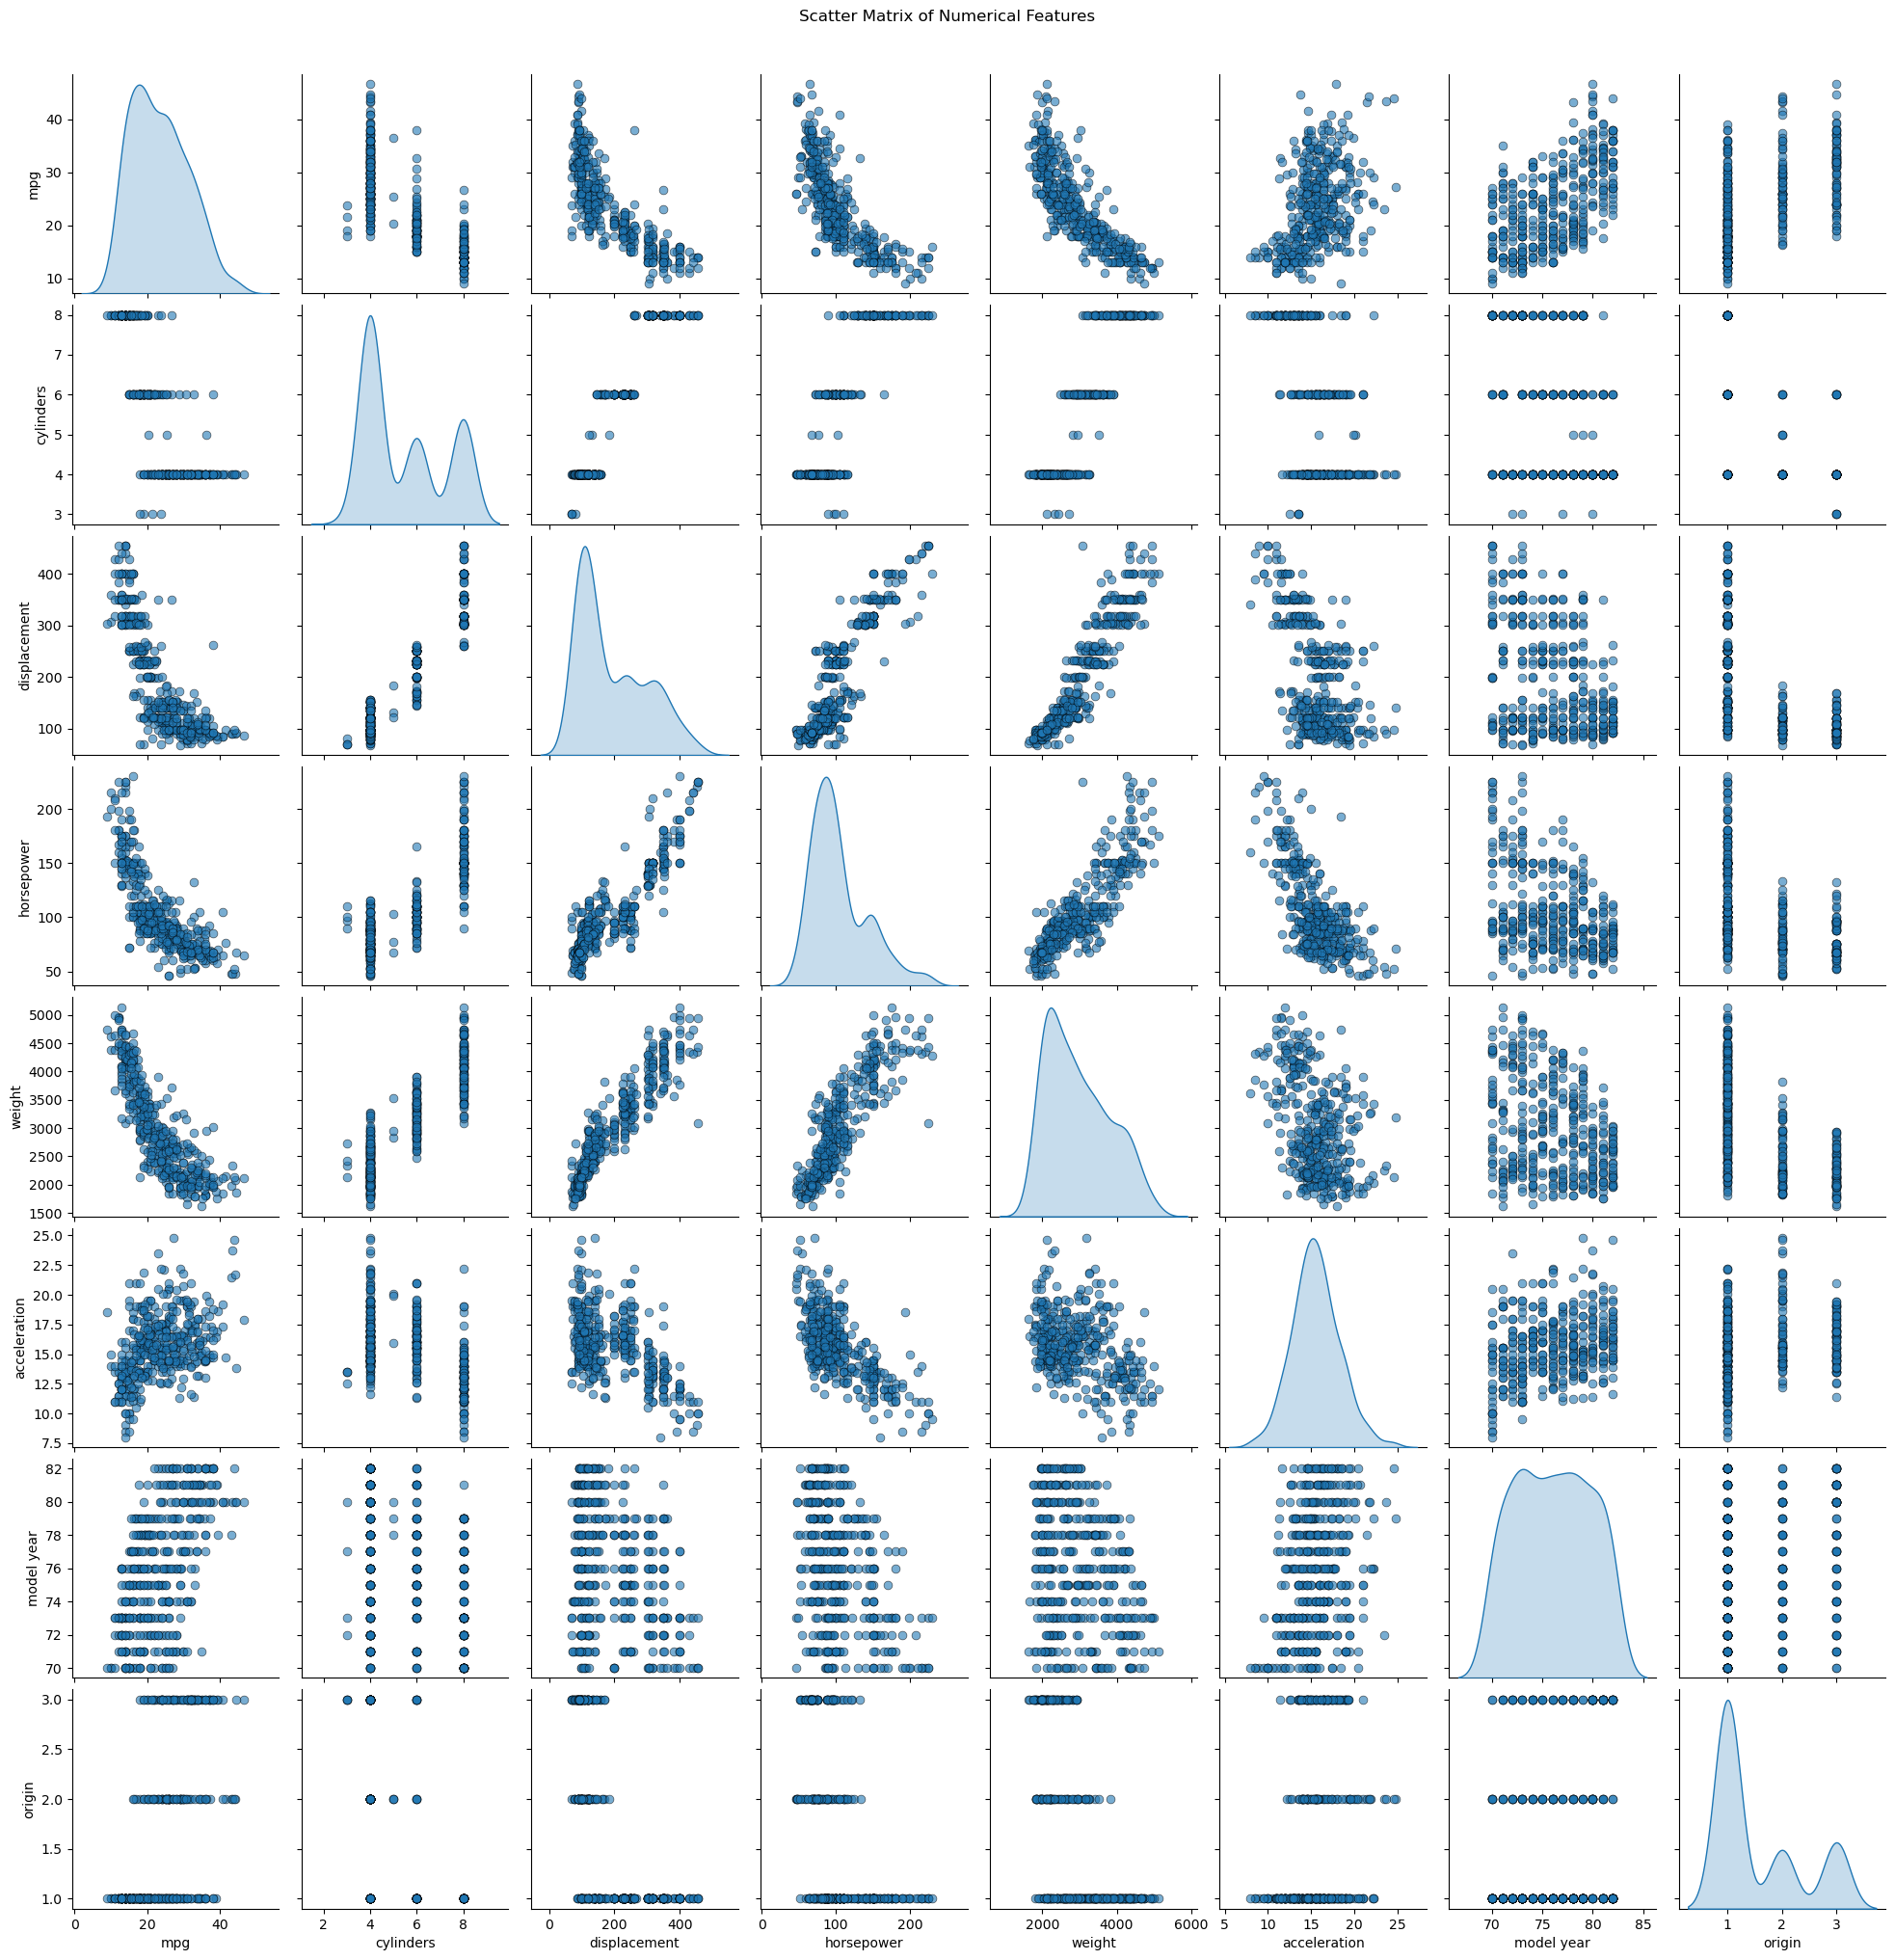

In [39]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])

sns.pairplot(numeric_df, diag_kind='kde',
             plot_kws={'alpha': 0.6, 's': 40, 'edgecolor': 'k'})
plt.suptitle("Scatter Matrix of Numerical Features", y=1.02)
plt.show()

In [40]:
X = df.drop(columns=['car name', 'origin'])

X = sm.add_constant(X)

vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif)

       Variable         VIF
0         const  757.031966
1           mpg    5.227504
2     cylinders   10.604849
3  displacement   19.765922
4    horsepower    8.644376
5        weight   13.429119
6  acceleration    2.510462
7    model year    1.910226


In [41]:
X = df.drop(columns=['car name', 'origin'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

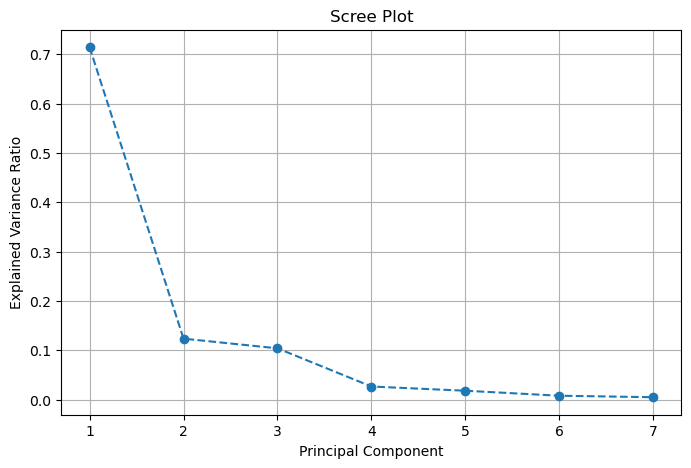

In [42]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
         pca.explained_variance_ratio_,
         marker='o', linestyle='--')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.xticks(range(1, len(pca.explained_variance_ratio_) + 1))
plt.show()

In [45]:
components = list(range(1, len(pca.explained_variance_ratio_) + 1))
variance_ratio = pca.explained_variance_ratio_

fig = px.line(
    x=components,
    y=variance_ratio,
    markers=True,
    labels={"x": "Principal Component", "y": "Explained Variance Ratio"},
    title="Scree Plot"
)

fig.show()

In [46]:
explained_variance = pd.DataFrame({
    "Principal Component": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "Explained Variance Ratio": pca.explained_variance_ratio_,
    "Cumulative Variance": np.cumsum(pca.explained_variance_ratio_)
})

print("\nExplained Variance per Principal Component:")
display(explained_variance.round(4))



Explained Variance per Principal Component:


,Principal Component,Explained Variance Ratio,Cumulative Variance
0,PC1,0.7142,0.7142
1,PC2,0.1237,0.8379
2,PC3,0.1041,0.9420
3,PC4,0.0267,0.9687
4,PC5,0.0182,0.9869
5,PC6,0.0081,0.9950
6,PC7,0.0050,1.0000


In [47]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(len(X.columns))],
    index=X.columns
)

print("\nPrincipal Component Loadings:")
display(loadings.round(4))


Principal Component Loadings:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7
mpg,-0.3979,0.2118,-0.2562,0.7477,0.3295,0.2356,-0.0898
cylinders,0.4166,0.1911,0.1409,0.4851,-0.4730,-0.3562,-0.4290
displacement,0.4299,0.1770,0.1037,0.2942,-0.0649,0.1465,0.8129
horsepower,0.4217,0.0918,-0.1680,-0.0393,0.7385,-0.4846,-0.0610
weight,0.4144,0.2215,0.2798,-0.1133,0.2264,0.7064,-0.3713
acceleration,-0.2848,-0.0245,0.8927,0.1262,0.2432,-0.2084,0.0534
model year,-0.2294,0.9106,-0.0172,-0.2980,-0.0877,-0.1371,0.0508


In [50]:
X_pca_3 = X_pca[:, :3]

df_pca = pd.DataFrame(X_pca_3, columns=['PC1', 'PC2', 'PC3'])

print("\nTop 3 Principal Components:")
display(df_pca.head(6))


Top 3 Principal Components:


,PC1,PC2,PC3
0,2.660088,-0.919219,-0.559197
1,3.521679,-0.789385,-0.671600
2,2.996660,-0.861310,-0.982945
3,2.935927,-0.949077,-0.608106
4,2.929128,-0.931849,-1.079775
5,4.685161,-0.392640,-1.010114


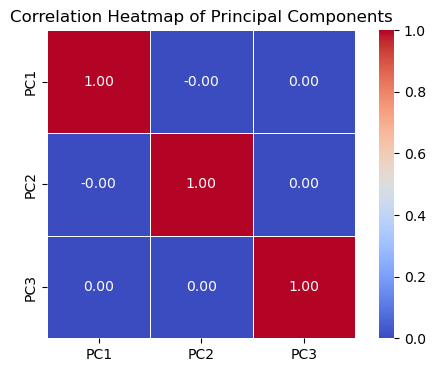

In [51]:
corr_pca = df_pca[['PC1', 'PC2', 'PC3']].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr_pca, annot=True, cmap='coolwarm', fmt='.2f', square=True, linewidths=0.5)
plt.title("Correlation Heatmap of Principal Components")
plt.show()

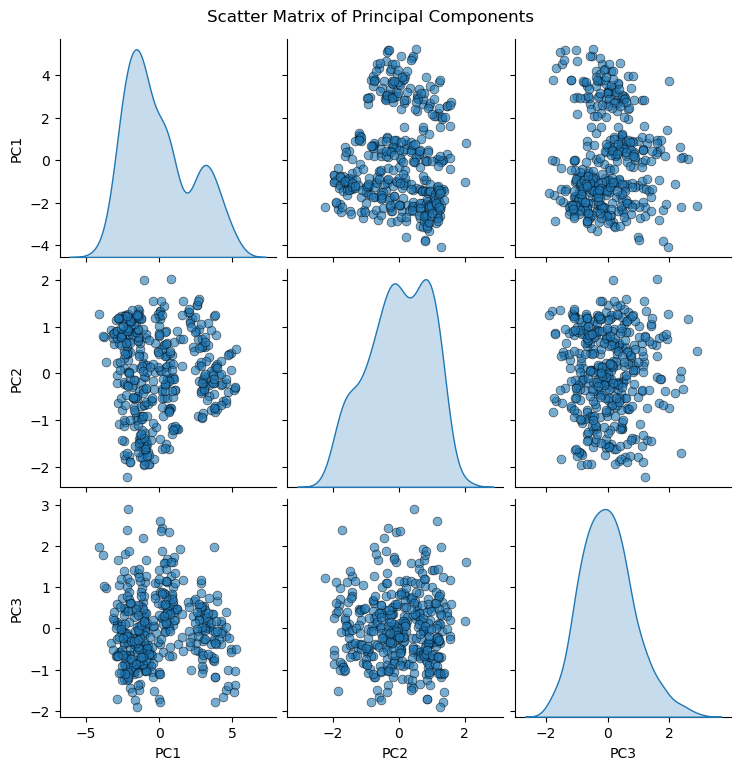

In [52]:
sns.pairplot(df_pca[['PC1', 'PC2', 'PC3']],
             diag_kind='kde',
             plot_kws={'alpha': 0.6, 's': 40, 'edgecolor': 'k'})
plt.suptitle("Scatter Matrix of Principal Components", y=1.02)
plt.show()